# 03 — Base models and hyperparameter tuning

Consume the **unscaled outputs of Notebook 2** without reconstructing features.

1. Tune on 2015 → 2016 using validation RMSE only.
2. Refit on 2015–2016 to generate 2017 forecasts for downstream ranking and stacking.
3. Refit on 2015–2017 to generate 2018 forecasts for final evaluation.
   
Required packages: NumPy, pandas, matplotlib, scikit-learn (with `BaggingRegressor(estimator=...)` support), XGBoost, LightGBM and TensorFlow. The full search trains eight ML families plus GRU and LSTM and can take substantial time.

Inputs: `day_ahead_features.npz`, `sample_metadata.csv`, `target_timestamps.csv`, both feature-name CSVs and `feature_manifest.json` under `data/features/`.

Outputs under `outputs/base_models/`: 2016 sensitivity tables, selected parameter CSVs, hourly `base_predictions_2017.csv` and `base_predictions_2018.csv`, base metric tables and an input/run manifest. Prediction files contain `time`, `y_true` and the ten ML/DL model columns; only eligible days exported by Notebook 2 are included. <br>
ETS is not trained here. Optional existing statistical forecasts may be merged in the final section.


In [2]:
from pathlib import Path
import json, random, time, warnings, hashlib
from functools import lru_cache
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, BaggingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURE_DIR = PROJECT_ROOT / 'data' / 'features'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'base_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STATISTICAL_DIR = PROJECT_ROOT   

N_RANDOM_CONFIGS = 10    
DL_MAX_EPOCHS = 60

ML_NAMES = ['LinearRegression','Ridge','ElasticNet','GradientBoosting',
            'RandomForest','XGBoost','LightGBM','Bagging']
DL_NAMES = ['GRU','LSTM']


## Load Notebook 2 outputs and validate alignment

The manifest supplies the timezone and feature dimensions. Array rows must match contiguous `sample_id` values; timestamp rows are ordered by sample and horizon. Delivery years come exclusively from sample metadata. No feature engineering or scaling occurs during loading.


In [4]:
required_files = ['day_ahead_features.npz', 'sample_metadata.csv',
                  'target_timestamps.csv', 'tabular_feature_names.csv',
                  'sequence_feature_names.csv', 'feature_manifest.json']

for filename in required_files:
    if not (FEATURE_DIR / filename).is_file():
        raise FileNotFoundError(f"Missing {FEATURE_DIR / filename}. Run Notebook 2 first or set PROJECT_ROOT.")

manifest = json.loads((FEATURE_DIR / 'feature_manifest.json').read_text())
TIMEZONE = manifest['timezone']
PRICE_WINDOW = int(manifest['price_window'])
HORIZON = int(manifest['forecast_horizon'])
CUTOFF_HOUR = int(manifest['forecast_origin_local_hour'])
TARGET = manifest['target']
CALENDAR_FEATURES = manifest['calendar_features']

if (PRICE_WINDOW, HORIZON, CUTOFF_HOUR) != (168, 24, 11):
    raise ValueError('Expected Notebook 2 protocol: 168-hour history, 24 targets, 11:00 origin.')

metadata = pd.read_csv(FEATURE_DIR / 'sample_metadata.csv')
timestamps = pd.read_csv(FEATURE_DIR / 'target_timestamps.csv').sort_values(['sample_id', 'horizon'])
tabular_names = pd.read_csv(FEATURE_DIR / 'tabular_feature_names.csv')['feature'].tolist()
sequence_names = pd.read_csv(FEATURE_DIR / 'sequence_feature_names.csv')['feature'].tolist()

with np.load(FEATURE_DIR / 'day_ahead_features.npz', allow_pickle=False) as archive:
    X_tabular, X_sequence, y = (archive[key].copy() for key in ('X_tabular', 'X_sequence', 'y'))
n_samples = len(metadata)

if not np.array_equal(metadata['sample_id'], np.arange(n_samples)):
    raise ValueError('Metadata rows must match zero-based array sample IDs.')

for array, expected, key in [(X_tabular, (n_samples, 201), 'tabular_shape'),
                              (X_sequence, (n_samples, 168, 34), 'sequence_shape'),
                              (y, (n_samples, 24), 'target_shape')]:
    if array.shape != expected or list(array.shape) != manifest[key] or not np.isfinite(array).all():
        raise ValueError(f'Invalid shape or non-finite values in {key}.')

if len(tabular_names) != 201 or len(sequence_names) != 34:
    raise ValueError('Feature-name dimensions do not match the arrays.')

if not np.array_equal(timestamps['sample_id'], np.repeat(np.arange(n_samples), HORIZON)):
    raise ValueError('Target timestamp sample IDs are incomplete or duplicated.')

if not np.array_equal(timestamps['horizon'], np.tile(np.arange(1, HORIZON + 1), n_samples)):
    raise ValueError('Expected horizons 1–24 for every sample.')
days = pd.DatetimeIndex(pd.to_datetime(metadata['delivery_day'])).tz_localize(TIMEZONE)

if not days.is_unique or not days.is_monotonic_increasing:
    raise ValueError('Delivery days must be unique and chronological.')

if not np.array_equal(days.year, metadata['delivery_year']) or set(days.year) != {2015, 2016, 2017, 2018}:
    raise ValueError('Invalid delivery-year metadata.')
target_index = pd.DatetimeIndex(pd.to_datetime(timestamps['target_timestamp'], utc=True)).tz_convert(TIMEZONE)

if not target_index.is_unique or not target_index.is_monotonic_increasing:
    raise ValueError('Target timestamps must be unique and chronological.')

if not np.array_equal(target_index.normalize().asi8, np.repeat(days.asi8, HORIZON)):
    raise ValueError('Target timestamps do not match delivery days.')

if not np.array_equal(target_index.hour, np.tile(np.arange(HORIZON), n_samples)):
    raise ValueError('Each sample must contain local delivery hours 00–23.')

if not np.array_equal(timestamps['delivery_day'], np.repeat(metadata['delivery_day'], HORIZON)):
    raise ValueError('Timestamp delivery-day labels are misaligned.')

origins = pd.DatetimeIndex(pd.to_datetime(metadata['forecast_origin'], utc=True)).tz_convert(TIMEZONE)
expected_origins = (days.tz_localize(None) - pd.Timedelta(days=1) + pd.Timedelta(hours=CUTOFF_HOUR)).tz_localize(TIMEZONE)

if not origins.equals(expected_origins):
    raise ValueError('Forecast origins must be 11:00 local time on D−1.')

price_end = pd.DatetimeIndex(pd.to_datetime(metadata['price_history_end'], utc=True))
price_start = pd.DatetimeIndex(pd.to_datetime(metadata['price_history_start'], utc=True))

if not np.array_equal(price_end.asi8, target_index[::HORIZON].asi8 - pd.Timedelta(hours=1).value):
    raise ValueError('Price histories must end immediately before delivery.')

if not ((price_end - price_start) == pd.Timedelta(hours=PRICE_WINDOW - 1)).all():
    raise ValueError('Incorrect price-history duration.')

if not np.array_equal(X_tabular[:, :PRICE_WINDOW], X_sequence[:, :, 0]):
    raise ValueError('Price-history representations disagree.')

if not np.allclose(X_sequence[:, :, 1:], X_tabular[:, None, PRICE_WINDOW:]):
    raise ValueError('Static sequence channels disagree with tabular predictors.')

samples = {'X_tab': X_tabular, 'X_seq': X_sequence, 'y': y,
           'days': days, 'years': metadata['delivery_year'].to_numpy(),
           'target_indices': [target_index[i:i + HORIZON] for i in range(0, len(target_index), HORIZON)]}

def subset(samples, years):
    mask = np.isin(samples['years'], years)
    if not mask.any():
        raise ValueError(f'No samples for {years}.')
    return {key: ([item for item, keep in zip(value, mask) if keep] if isinstance(value, list)
                  else value[mask]) for key, value in samples.items()}

# Timestamp-indexed training targets allow exact elapsed-24-hour MASE comparisons.
training_targets = pd.Series(y.ravel().astype(float), index=target_index)
display(metadata.groupby('delivery_year').size().rename('eligible_days'))
run_manifest = {'features': manifest, 'seed': SEED, 'selection_year': 2016,
                'input_sha256': {name: hashlib.sha256((FEATURE_DIR / name).read_bytes()).hexdigest()
                                 for name in required_files},
                'n_random_configs': N_RANDOM_CONFIGS, 'dl_max_epochs': DL_MAX_EPOCHS}
(OUTPUT_DIR / 'run_manifest.json').write_text(json.dumps(run_manifest, indent=2))


delivery_year
2015    355
2016    364
2017    363
2018    363
Name: eligible_days, dtype: int64

1446

In [5]:
feature_audit = pd.DataFrame({'input': ['Historical prices', 'Origin exogenous summaries',
    'Delivery calendar', 'Tabular total', 'Sequence channels', 'Output horizons'],
    'count': [PRICE_WINDOW, 28, len(CALENDAR_FEATURES), len(tabular_names), len(sequence_names), HORIZON]})
display(feature_audit)


,input,count
0,Historical prices,168
1,Origin exogenous summaries,28
2,Delivery calendar,5
3,Tabular total,201
4,Sequence channels,34
5,Output horizons,24


## Metrics and estimator construction

Validation RMSE is the prespecified tuning criterion. MAE, MAPE, R² and MASE are retained for the sensitivity table.  

MASE uses only training-year targets exported by Notebook 2, paired with targets exactly 24 elapsed hours earlier. Missing pairs (including excluded DST days) are omitted, so this denominator can differ slightly from the original notebook's full hourly-series denominator. MAPE clips absolute prices at 1e-6. All metrics pool the 24 horizons.


In [7]:
@lru_cache(maxsize=None)
def _mase_scale(years):
    history = training_targets.loc[training_targets.index.year.isin(years)]
    lagged = history.reindex(history.index - pd.Timedelta(hours=24)).to_numpy()
    valid = np.isfinite(lagged)
    scale = np.mean(np.abs(history.to_numpy()[valid] - lagged[valid])) if valid.any() else np.nan
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError(f'Undefined training MASE scale for {years}.')
    return float(scale)

def mase_denominator(years):
    return _mase_scale(tuple(years))

def metrics(y, pred, train_years):
    yt, yp = np.asarray(y).ravel(), np.asarray(pred).ravel()
    mae = mean_absolute_error(yt, yp)
    return {'MAE':mae, 'RMSE':mean_squared_error(yt,yp)**0.5,
            'MAPE':np.mean(np.abs((yt-yp)/np.clip(np.abs(yt),1e-6,None)))*100,
            'R2':r2_score(yt,yp), 'MASE':mae/mase_denominator(train_years)}

def base_ml_model(name, p):
    if name == 'LinearRegression': return LinearRegression()
    if name == 'Ridge': return Ridge(random_state=SEED, **p)
    if name == 'ElasticNet': return ElasticNet(random_state=SEED, max_iter=10000, **p)
    if name == 'GradientBoosting': return GradientBoostingRegressor(random_state=SEED, **p)
    if name == 'RandomForest': return RandomForestRegressor(random_state=SEED, n_jobs=-1, **p)
    if name == 'XGBoost': return XGBRegressor(random_state=SEED, n_jobs=-1, objective='reg:squarederror', **p)
    if name == 'LightGBM': return LGBMRegressor(random_state=SEED, n_jobs=-1, verbosity=-1, **p)
    if name == 'Bagging':
        depth = p.pop('tree_max_depth')
        return BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=depth, random_state=SEED),
                                random_state=SEED, n_jobs=-1, **p)
    raise KeyError(name)

def make_ml_model(name, params):
    base = base_ml_model(name, dict(params))
    if name in {'ElasticNet','GradientBoosting','XGBoost','LightGBM'}:
        base = MultiOutputRegressor(base, n_jobs=1)
    if name in {'LinearRegression','Ridge','ElasticNet'}:
        return Pipeline([('scaler',StandardScaler()),('model',base)])
    return base


## Compact, reproducible search spaces

The spaces vary the principal capacity and regularisation parameters without attempting an expensive exhaustive optimization. `ParameterSampler` uses a fixed seed, making the sensitivity analysis reproducible.


In [9]:
BASELINE_PARAMS = {
 'LinearRegression': {}, 'Ridge': {'alpha':1.0},
 'ElasticNet': {'alpha':0.1,'l1_ratio':0.5},
 'GradientBoosting': {'n_estimators':100,'learning_rate':0.1,'max_depth':3},
 'RandomForest': {'n_estimators':600,'max_depth':None,'min_samples_leaf':1,'max_features':1.0},
 'XGBoost': {'n_estimators':1200,'learning_rate':0.05,'max_depth':6,'subsample':0.9,'colsample_bytree':0.9,'reg_lambda':1.0},
 'LightGBM': {'n_estimators':2000,'learning_rate':0.03,'num_leaves':63,'min_child_samples':20,'subsample':0.9,'colsample_bytree':0.9},
 'Bagging': {'n_estimators':200,'max_samples':1.0,'max_features':1.0,'tree_max_depth':None}
}

SEARCH_SPACES = {
 'LinearRegression': [{}],
 'Ridge': {'alpha':[0.01,0.1,1.0,10.0,100.0]},
 'ElasticNet': {'alpha':[0.001,0.01,0.1,1.0], 'l1_ratio':[0.1,0.5,0.9]},
 'GradientBoosting': {'n_estimators':[100,300,500], 'learning_rate':[0.03,0.05,0.1], 'max_depth':[2,3,5], 'min_samples_leaf':[1,5,10]},
 'RandomForest': {'n_estimators':[300,600], 'max_depth':[None,10,20], 'min_samples_leaf':[1,5,10], 'max_features':[0.5,0.75,1.0]},
 'XGBoost': {'n_estimators':[500,1000], 'learning_rate':[0.03,0.05,0.1], 'max_depth':[3,6,9], 'subsample':[0.8,1.0], 'colsample_bytree':[0.8,1.0], 'reg_lambda':[1.0,5.0]},
 'LightGBM': {'n_estimators':[500,1000], 'learning_rate':[0.03,0.05,0.1], 'num_leaves':[31,63,127], 'min_child_samples':[20,50], 'subsample':[0.8,1.0], 'subsample_freq':[0,1], 'colsample_bytree':[0.8,1.0]},
 'Bagging': {'n_estimators':[100,300], 'max_samples':[0.7,1.0], 'max_features':[0.7,1.0], 'tree_max_depth':[None,10,20]}
}

def candidates(name):
    space = SEARCH_SPACES[name]
    if isinstance(space, list): return space
    total = np.prod([len(v) for v in space.values()])
    return list(ParameterSampler(space, n_iter=min(N_RANDOM_CONFIGS,int(total)), random_state=SEED))


## Tune ML models using 2015→2016 only

Both the submitted fixed configuration and every candidate are evaluated, allowing the paper to report the sensitivity of each model to tuning rather than only the optimized result.


In [11]:
s15, s16 = subset(samples,[2015]), subset(samples,[2016])
ml_search_rows, best_ml_params = [], {}

for name in ML_NAMES:
    tested = [BASELINE_PARAMS[name]]
    tested += [p for p in candidates(name) if p != BASELINE_PARAMS[name]]
    seen = set(); tested = [p for p in tested if not (json.dumps(p,sort_keys=True,default=str) in seen or seen.add(json.dumps(p,sort_keys=True,default=str)))]
    print(f'\n{name}: {len(tested)} configurations')
    for i,p in enumerate(tested):
        start=time.time(); model=make_ml_model(name,p)
        model.fit(s15['X_tab'],s15['y']); pred=model.predict(s16['X_tab'])
        row={'model':name,'configuration':i,'is_submitted_configuration':i==0,
             'parameters':json.dumps(p,sort_keys=True,default=str),
             'runtime_minutes':(time.time()-start)/60, **metrics(s16['y'],pred,[2015])}
        ml_search_rows.append(row); print(i, 'RMSE', round(row['RMSE'],3))
    model_rows=[r for r in ml_search_rows if r['model']==name]
    best_ml_params[name]=json.loads(min(model_rows,key=lambda r:r['RMSE'])['parameters'])

ml_sensitivity=pd.DataFrame(ml_search_rows)
ml_sensitivity.to_csv(OUTPUT_DIR/'ml_hyperparameter_sensitivity_2016.csv',index=False)
pd.DataFrame([{'model':k,'selected_parameters':json.dumps(v,sort_keys=True)} for k,v in best_ml_params.items()]).to_csv(OUTPUT_DIR/'selected_ml_hyperparameters.csv',index=False)
ml_sensitivity.sort_values(['model','RMSE']).groupby('model').head(3)



LinearRegression: 1 configurations
0 RMSE 14.349

Ridge: 5 configurations
0 RMSE 12.689
1 RMSE 14.287
2 RMSE 13.872
3 RMSE 11.456
4 RMSE 10.828

ElasticNet: 10 configurations
0 RMSE 10.923
1 RMSE 11.505
2 RMSE 11.19
3 RMSE 13.322
4 RMSE 10.929
5 RMSE 12.402
6 RMSE 13.915
7 RMSE 13.545
8 RMSE 11.848
9 RMSE 12.128

GradientBoosting: 11 configurations
0 RMSE 12.578
1 RMSE 12.486
2 RMSE 12.816
3 RMSE 12.608
4 RMSE 12.428
5 RMSE 12.837
6 RMSE 12.473
7 RMSE 12.63
8 RMSE 12.472
9 RMSE 12.389
10 RMSE 12.639

RandomForest: 11 configurations
0 RMSE 12.333
1 RMSE 12.236
2 RMSE 12.334
3 RMSE 12.264
4 RMSE 12.263
5 RMSE 12.353
6 RMSE 12.568
7 RMSE 12.545
8 RMSE 12.507
9 RMSE 12.32
10 RMSE 12.467

XGBoost: 11 configurations
0 RMSE 12.888
1 RMSE 13.413
2 RMSE 13.985
3 RMSE 13.63
4 RMSE 12.791
5 RMSE 12.924
6 RMSE 12.839
7 RMSE 12.933
8 RMSE 13.213
9 RMSE 14.004
10 RMSE 13.952

LightGBM: 11 configurations
0 RMSE 12.852
1 RMSE 12.932
2 RMSE 13.054
3 RMSE 12.914
4 RMSE 13.018
5 RMSE 12.978
6 RMSE 13.02

,model,configuration,is_submitted_configuration,parameters,runtime_minutes,MAE,RMSE,MAPE,R2,MASE
67,Bagging,7,False,"{""max_features"": 1.0, ""max_samples"": 0.7, ""n_e...",0.008501,8.953072,11.975980,46.768976,0.349931,1.035150
62,Bagging,2,False,"{""max_features"": 1.0, ""max_samples"": 0.7, ""n_e...",0.021734,9.019152,12.024682,46.818570,0.344633,1.042790
70,Bagging,10,False,"{""max_features"": 0.7, ""max_samples"": 0.7, ""n_e...",0.016728,9.133437,12.111521,47.213947,0.335133,1.056004
6,ElasticNet,0,True,"{""alpha"": 0.1, ""l1_ratio"": 0.5}",0.001681,8.335097,10.922981,40.035930,0.459221,0.963700
10,ElasticNet,4,False,"{""alpha"": 0.1, ""l1_ratio"": 0.9}",0.002995,8.331557,10.929308,39.940807,0.458594,0.963291
8,ElasticNet,2,False,"{""alpha"": 1.0, ""l1_ratio"": 0.1}",0.001254,8.528033,11.190402,42.279580,0.432418,0.986007
25,GradientBoosting,9,False,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.825258,9.213993,12.388601,47.311208,0.304364,1.065318
20,GradientBoosting,4,False,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",0.822517,9.208040,12.427803,47.342126,0.299955,1.064629
24,GradientBoosting,8,False,"{""learning_rate"": 0.1, ""max_depth"": 3, ""min_sa...",1.182873,9.300827,12.472115,47.706301,0.294954,1.075357
57,LightGBM,8,False,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.111278,9.556284,12.797328,50.172985,0.257706,1.104893


## Extended Ridge regularisation sensitivity

Evaluate the union of the original and extended alpha grids. Select globally using 2016 RMSE and propagate that same result to the summary and both forecast windows. A boundary winner is reported as a warning, not an execution failure.


Selected Ridge alpha: 100


,model,configuration,is_submitted_configuration,parameters,runtime_minutes,MAE,RMSE,MAPE,R2,MASE,alpha
0,Ridge,1,False,"{""alpha"": 0.01}",0.000051,11.296289,14.287028,47.746360,0.074831,1.306072,0.01
1,Ridge,2,False,"{""alpha"": 0.1}",0.000056,10.969727,13.872334,46.988699,0.127759,1.268315,0.10
2,Ridge,0,True,"{""alpha"": 1.0}",0.000065,9.978375,12.688876,44.871292,0.270234,1.153695,1.00
3,Ridge,3,False,"{""alpha"": 10.0}",0.000099,8.841958,11.456098,41.927713,0.405145,1.022303,10.00
4,Ridge,extended,False,"{""alpha"": 30.0}",0.000107,8.432206,11.015935,40.535596,0.449978,0.974928,30.00
5,Ridge,4,False,"{""alpha"": 100.0}",0.000029,8.237228,10.828009,40.176323,0.468584,0.952384,100.00
6,Ridge,extended,False,"{""alpha"": 300.0}",0.000034,8.403842,11.038184,41.606212,0.447754,0.971648,300.00
7,Ridge,extended,False,"{""alpha"": 1000.0}",0.000193,9.006308,11.733669,45.142975,0.375970,1.041305,1000.00
8,Ridge,extended,False,"{""alpha"": 3000.0}",0.000147,9.826960,12.695275,49.700373,0.269498,1.136188,3000.00


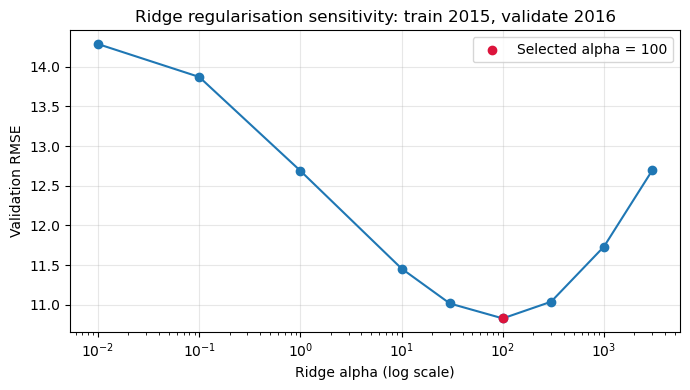

In [13]:
RIDGE_EXTENDED_ALPHAS = [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0]
ridge_rows = []

for alpha in RIDGE_EXTENDED_ALPHAS:
    start = time.time()
    params = {'alpha': alpha}
    model = make_ml_model('Ridge', params)
    model.fit(s15['X_tab'], s15['y'])
    prediction = np.asarray(model.predict(s16['X_tab']))

    ridge_rows.append({
        'model': 'Ridge',
        'alpha': alpha,
        'runtime_minutes': (time.time() - start) / 60,
        **metrics(s16['y'], prediction, train_years=[2015])
    })

ridge_sensitivity = (
    pd.DataFrame(ridge_rows)
    .sort_values('alpha')
    .reset_index(drop=True)
)

extra = ridge_sensitivity.copy()
extra['parameters'] = extra['alpha'].map(lambda value: json.dumps({'alpha': float(value)}, sort_keys=True))
extra['is_submitted_configuration'] = False
extra['configuration'] = 'extended'
ml_sensitivity = pd.concat([ml_sensitivity, extra.drop(columns='alpha')], ignore_index=True)
ml_sensitivity = ml_sensitivity.drop_duplicates(['model', 'parameters'], keep='first')
ridge_all = ml_sensitivity.loc[ml_sensitivity.model.eq('Ridge')].copy()
ridge_all['alpha'] = ridge_all.parameters.map(lambda value: float(json.loads(value)['alpha']))
ridge_sensitivity = ridge_all.sort_values('alpha').reset_index(drop=True)
best_ridge_row = ridge_sensitivity.loc[ridge_sensitivity['RMSE'].idxmin()]
best_ridge_alpha = float(best_ridge_row['alpha'])
best_ml_params['Ridge'] = {'alpha': best_ridge_alpha}
ml_sensitivity.to_csv(OUTPUT_DIR / 'ml_hyperparameter_sensitivity_2016.csv', index=False)

print(f'Selected Ridge alpha: {best_ridge_alpha:g}')
display(ridge_sensitivity)

ridge_sensitivity.to_csv(
    OUTPUT_DIR / 'ridge_extended_sensitivity_2016.csv', index=False
)

# Rewrite the selected-parameter file after the extended check.
pd.DataFrame([
    {'model': name, 'selected_parameters': json.dumps(params, sort_keys=True)}
    for name, params in best_ml_params.items()
]).to_csv(OUTPUT_DIR / 'selected_ml_hyperparameters.csv', index=False)

plt.figure(figsize=(7, 4))
plt.semilogx(ridge_sensitivity['alpha'], ridge_sensitivity['RMSE'], marker='o')
plt.scatter([best_ridge_alpha], [best_ridge_row['RMSE']], color='crimson', zorder=3,
            label=f'Selected alpha = {best_ridge_alpha:g}')
plt.xlabel('Ridge alpha (log scale)')
plt.ylabel('Validation RMSE')
plt.title('Ridge regularisation sensitivity: train 2015, validate 2016')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ridge_extended_sensitivity_2016.png', dpi=300,
            bbox_inches='tight')
plt.show()

if best_ridge_alpha in (ridge_sensitivity.alpha.min(), ridge_sensitivity.alpha.max()):
    warnings.warn('Ridge winner lies on the tested boundary; consider extending the grid using 2016 only.')


## Tune GRU and LSTM using 2015→2016 only

For each candidate, the last 45 complete days of 2015 control early stopping. The independent 2016 year determines the winning hyperparameter configuration.


In [15]:
DL_CONFIGS = [
 {'units':64,'dense_units':64,'dropout':0.1,'learning_rate':1e-3,'batch_size':256}, # submitted configuration
 {'units':32,'dense_units':32,'dropout':0.0,'learning_rate':1e-3,'batch_size':32},
 {'units':32,'dense_units':64,'dropout':0.2,'learning_rate':1e-3,'batch_size':64},
 {'units':64,'dense_units':32,'dropout':0.0,'learning_rate':5e-4,'batch_size':32},
 {'units':64,'dense_units':64,'dropout':0.1,'learning_rate':5e-4,'batch_size':64},
 {'units':64,'dense_units':64,'dropout':0.2,'learning_rate':1e-3,'batch_size':64},
 {'units':128,'dense_units':64,'dropout':0.1,'learning_rate':5e-4,'batch_size':64},
 {'units':128,'dense_units':64,'dropout':0.2,'learning_rate':1e-4,'batch_size':32},
 {'units':64,'dense_units':128,'dropout':0.2,'learning_rate':1e-4,'batch_size':64},
]

def build_dl(kind,n_features,p):
    keras.backend.clear_session(); keras.utils.set_random_seed(SEED)
    inp=keras.Input((PRICE_WINDOW,n_features)); R=layers.GRU if kind=='GRU' else layers.LSTM
    x=R(p['units'],dropout=p['dropout'])(inp)
    x=layers.Dense(p['dense_units'],activation='relu')(x); out=layers.Dense(HORIZON)(x)
    m=keras.Model(inp,out); m.compile(keras.optimizers.Adam(p['learning_rate']),loss='mse'); return m

def fit_predict_dl(train,test,kind,p,val_days=45):
    if len(train['y']) <= val_days:
        raise ValueError('Insufficient training days for early stopping.')
    split=len(train['y'])-val_days
    Xfit,Xval=train['X_seq'][:split],train['X_seq'][split:]
    yfit,yval=train['y'][:split],train['y'][split:]
    nf=Xfit.shape[2]; sx=StandardScaler().fit(Xfit.reshape(-1,nf)); sy=StandardScaler().fit(yfit)
    tx=lambda x:sx.transform(x.reshape(-1,nf)).reshape(x.shape)
    model=build_dl(kind,nf,p)
    cb=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=4,factor=.5,min_lr=1e-5)]
    hist=model.fit(tx(Xfit),sy.transform(yfit),validation_data=(tx(Xval),sy.transform(yval)),
                   epochs=DL_MAX_EPOCHS,batch_size=p['batch_size'],verbose=0,callbacks=cb,shuffle=False)
    pred=sy.inverse_transform(model.predict(tx(test['X_seq']),verbose=0))
    return pred, len(hist.history['loss'])

dl_search_rows,best_dl_params={},{}
dl_search_rows=[]
for kind in DL_NAMES:
    print('\nTuning',kind)
    for i,p in enumerate(DL_CONFIGS):
        start=time.time(); pred,epochs=fit_predict_dl(s15,s16,kind,p)
        row={'model':kind,'configuration':i,'is_submitted_configuration':i==0,'parameters':json.dumps(p,sort_keys=True),
             'epochs_run':epochs,'runtime_minutes':(time.time()-start)/60,
             **metrics(s16['y'],pred,[2015])}
        dl_search_rows.append(row); print(i,'RMSE',round(row['RMSE'],3),'epochs',epochs)
    rows=[r for r in dl_search_rows if r['model']==kind]
    best_dl_params[kind]=json.loads(min(rows,key=lambda r:r['RMSE'])['parameters'])

dl_sensitivity=pd.DataFrame(dl_search_rows)
dl_sensitivity.to_csv(OUTPUT_DIR/'dl_hyperparameter_sensitivity_2016.csv',index=False)
pd.DataFrame([{'model':k,'selected_parameters':json.dumps(v,sort_keys=True)} for k,v in best_dl_params.items()]).to_csv(OUTPUT_DIR/'selected_dl_hyperparameters.csv',index=False)
dl_sensitivity.sort_values(['model','RMSE']).groupby('model').head(3)



Tuning GRU
0 RMSE 13.112 epochs 58
1 RMSE 12.753 epochs 34
2 RMSE 13.343 epochs 45
3 RMSE 12.47 epochs 42
4 RMSE 12.879 epochs 54
5 RMSE 13.002 epochs 35
6 RMSE 12.5 epochs 44
7 RMSE 14.465 epochs 60
8 RMSE 16.605 epochs 60

Tuning LSTM
0 RMSE 15.485 epochs 34
1 RMSE 16.155 epochs 20
2 RMSE 15.101 epochs 38
3 RMSE 14.634 epochs 29
4 RMSE 14.088 epochs 41
5 RMSE 13.981 epochs 36
6 RMSE 14.578 epochs 30
7 RMSE 14.841 epochs 60
8 RMSE 16.515 epochs 60


,model,configuration,is_submitted_configuration,parameters,epochs_run,runtime_minutes,MAE,RMSE,MAPE,R2,MASE
3,GRU,3,False,"{""batch_size"": 32, ""dense_units"": 32, ""dropout...",42,0.187798,9.793996,12.470073,45.121276,0.295184,1.132377
6,GRU,6,False,"{""batch_size"": 64, ""dense_units"": 64, ""dropout...",44,0.354069,9.919169,12.499680,45.788038,0.291834,1.146850
1,GRU,1,False,"{""batch_size"": 32, ""dense_units"": 32, ""dropout...",34,0.112122,10.137820,12.753105,47.012374,0.262827,1.172130
14,LSTM,5,False,"{""batch_size"": 64, ""dense_units"": 64, ""dropout...",36,0.139917,11.265064,13.981064,52.350986,0.114032,1.302461
13,LSTM,4,False,"{""batch_size"": 64, ""dense_units"": 64, ""dropout...",41,0.155998,11.398170,14.087712,53.887755,0.100464,1.317851
15,LSTM,6,False,"{""batch_size"": 64, ""dense_units"": 64, ""dropout...",30,0.244959,11.773165,14.577557,54.245299,0.036821,1.361208


## Fit selected models and generate 2017/2018 predictions

The same selected hyperparameters are used in both windows. ML models fit all training samples. As in the source notebook, recurrent models reserve the last 60 eligible training days for early stopping; their scalers fit only the earlier training portion. No prediction-year targets enter fitting or early stopping. Run the preceding cells first.

Output timestamps come directly from Notebook 2; excluded days are omitted rather than filled or forecast.


In [17]:
def flatten_predictions(test_samples, predictions, test_year):
    idx = pd.DatetimeIndex(np.concatenate([x.to_numpy() for x in test_samples['target_indices']]))
    out = pd.DataFrame({'y_true': test_samples['y'].ravel()}, index=idx)
    for name, matrix in predictions.items():
        matrix = np.asarray(matrix)
        if matrix.shape != test_samples['y'].shape or not np.isfinite(matrix).all():
            raise ValueError(f'Invalid predictions for {name}.')
        out[name] = matrix.ravel()
    if not (out.index.year == test_year).all():
        raise ValueError('Prediction year mismatch.')
    return out

def train_selected_window(train_years,test_year):
    train,test=subset(samples,train_years),subset(samples,[test_year]); preds={}
    for name in ML_NAMES:
        print(test_year,name); m=make_ml_model(name,best_ml_params[name]); m.fit(train['X_tab'],train['y'])
        preds[name]=np.asarray(m.predict(test['X_tab']))
    for kind in DL_NAMES:
        print(test_year,kind); preds[kind],_=fit_predict_dl(train,test,kind,best_dl_params[kind],val_days=60)
    return flatten_predictions(test,preds,test_year)

tuned2017=train_selected_window([2015,2016],2017)
tuned2017.to_csv(OUTPUT_DIR/'tuned_ml_dl_predictions_2017.csv',index_label='time')
tuned2018=train_selected_window([2015,2016,2017],2018)
tuned2018.to_csv(OUTPUT_DIR/'tuned_ml_dl_predictions_2018.csv',index_label='time')

for year, frame in [(2017, tuned2017), (2018, tuned2018)]:
    frame.to_csv(OUTPUT_DIR / f'base_predictions_{year}.csv', index_label='time')


2017 LinearRegression
2017 Ridge
2017 ElasticNet
2017 GradientBoosting
2017 RandomForest
2017 XGBoost
2017 LightGBM
2017 Bagging
2017 GRU
2017 LSTM
2018 LinearRegression
2018 Ridge
2018 ElasticNet
2018 GradientBoosting
2018 RandomForest
2018 XGBoost
2018 LightGBM
2018 Bagging
2018 GRU
2018 LSTM


In [18]:
# Evaluate tuned ML/DL models on a common set of complete days.
def evaluate_tuned_frame(frame, train_years, year):
    model_cols = ML_NAMES + DL_NAMES
    valid = frame[['y_true', *model_cols]].notna().all(axis=1)
    valid_days = frame.index[valid].normalize().value_counts()
    valid_days = valid_days[valid_days.eq(24)].index
    common = valid & frame.index.normalize().isin(valid_days)
    rows = []
    for name in model_cols:
        rows.append({'year': year, 'model': name, 'n_forecasts': int(common.sum()),
                     **metrics(frame.loc[common,'y_true'], frame.loc[common,name], train_years)})
    return pd.DataFrame(rows).sort_values('RMSE')

tuned_metrics_2017 = evaluate_tuned_frame(tuned2017, [2015,2016], 2017)
tuned_metrics_2018 = evaluate_tuned_frame(tuned2018, [2015,2016,2017], 2018)
tuned_metrics_2017.to_csv(OUTPUT_DIR/'tuned_base_metrics_2017.csv', index=False)
tuned_metrics_2018.to_csv(OUTPUT_DIR/'tuned_base_metrics_2018.csv', index=False)
print('2017 tuned base models')
display(tuned_metrics_2017)
print('2018 tuned base models')
display(tuned_metrics_2018)

for year, table in [(2017, tuned_metrics_2017), (2018, tuned_metrics_2018)]:
    table.to_csv(OUTPUT_DIR / f'base_metrics_{year}.csv', index=False)


2017 tuned base models


,year,model,n_forecasts,MAE,RMSE,MAPE,R2,MASE
2,2017,ElasticNet,8712,6.568206,9.058915,14.937247,0.454997,0.799840
1,2017,Ridge,8712,6.584695,9.095931,14.990398,0.450535,0.801848
6,2017,LightGBM,8712,7.018706,9.761243,15.305289,0.367215,0.854699
3,2017,GradientBoosting,8712,7.064918,9.999277,15.389240,0.335977,0.860327
5,2017,XGBoost,8712,7.341142,10.408648,15.803488,0.280493,0.893964
8,2017,GRU,8712,7.682230,10.574822,16.530052,0.257336,0.935500
0,2017,LinearRegression,8712,8.080967,10.619462,17.585978,0.251053,0.984056
9,2017,LSTM,8712,7.901309,10.746463,16.841379,0.233032,0.962178
4,2017,RandomForest,8712,7.656858,11.262030,16.224574,0.157675,0.932410
7,2017,Bagging,8712,7.761443,11.340795,16.348340,0.145852,0.945146


2018 tuned base models


,year,model,n_forecasts,MAE,RMSE,MAPE,R2,MASE
2,2018,ElasticNet,8712,6.497337,8.809482,20.923403,0.526501,0.822063
1,2018,Ridge,8712,6.514845,8.838503,21.139309,0.523376,0.824278
8,2018,GRU,8712,7.241137,9.496407,22.062740,0.449780,0.916171
0,2018,LinearRegression,8712,7.022269,9.505107,22.303888,0.448771,0.888479
6,2018,LightGBM,8712,7.229826,9.893848,23.652188,0.402761,0.914740
3,2018,GradientBoosting,8712,7.587160,10.081128,23.282311,0.379936,0.959951
5,2018,XGBoost,8712,7.828542,10.581493,24.526882,0.316857,0.990491
4,2018,RandomForest,8712,8.317300,10.826452,24.183182,0.284861,1.052330
9,2018,LSTM,8712,8.801432,10.907489,24.630508,0.274115,1.113584
7,2018,Bagging,8712,8.501351,10.998472,24.425931,0.261955,1.075617


## Optional merge with existing statistical forecasts

If `STATISTICAL_DIR/base_predictions_YEAR.csv` exists, align its additional model columns by UTC timestamp and check target agreement. Save the result separately as `combined_base_predictions_YEAR.csv`; the ML/DL base outputs always exist independently. This notebook does not train ETS or certify how external forecasts were generated. Only reuse statistical predictions with the same information-availability protocol.


In [20]:
def merge_with_statistical(year, tuned):
    path = STATISTICAL_DIR / f'base_predictions_{year}.csv'
    if not path.exists():
        print(f'{path.name}: no optional statistical input; ML/DL exports are complete.')
        return None
    old = pd.read_csv(path)
    old.index = pd.DatetimeIndex(pd.to_datetime(old.pop('time'), utc=True)).tz_convert(TIMEZONE)
    if not old.index.is_unique:
        raise ValueError(f'Duplicate timestamps in {path}.')
    aligned = old.reindex(tuned.index)
    if 'y_true' not in aligned or not np.allclose(aligned['y_true'], tuned['y_true'], rtol=1e-5, atol=1e-4):
        raise ValueError(f'Missing or inconsistent targets in {path}.')
    extra_columns = [name for name in old if name not in ['y_true', *ML_NAMES, *DL_NAMES]]
    combined = tuned.join(aligned[extra_columns])
    combined.to_csv(OUTPUT_DIR / f'combined_base_predictions_{year}.csv', index_label='time')
    print(year, 'additional columns:', extra_columns)
    return combined

combined2017 = merge_with_statistical(2017, tuned2017)
combined2018 = merge_with_statistical(2018, tuned2018)


base_predictions_2017.csv: no optional statistical input; ML/DL exports are complete.
base_predictions_2018.csv: no optional statistical input; ML/DL exports are complete.


## Reviewer-facing sensitivity summary

The table compares each submitted fixed configuration with its selected configuration on the independent 2016 tuning year. Linear Regression is retained as the no-hyperparameter reference.


In [22]:
rows=[]
for name in ML_NAMES:
    d=ml_sensitivity[ml_sensitivity.model==name]
    base=d[d.is_submitted_configuration].iloc[0]; best=d.loc[d.RMSE.idxmin()]
    rows.append({'model':name,'submitted_RMSE':base.RMSE,'tuned_RMSE':best.RMSE,
                 'RMSE_improvement_percent':100*(base.RMSE-best.RMSE)/base.RMSE,
                 'selected_parameters':best.parameters})
for name in DL_NAMES:
    d=dl_sensitivity[dl_sensitivity.model==name]; base=d[d.is_submitted_configuration].iloc[0]; best=d.loc[d.RMSE.idxmin()]
    rows.append({'model':name,'submitted_RMSE':base.RMSE,'tuned_RMSE':best.RMSE,
                 'RMSE_improvement_percent':100*(base.RMSE-best.RMSE)/base.RMSE,'selected_parameters':best.parameters})
sensitivity_summary=pd.DataFrame(rows).sort_values('tuned_RMSE')
sensitivity_summary.to_csv(OUTPUT_DIR/'hyperparameter_sensitivity_summary.csv',index=False)
sensitivity_summary


,model,submitted_RMSE,tuned_RMSE,RMSE_improvement_percent,selected_parameters
1,Ridge,12.688876,10.828009,14.665341,"{""alpha"": 100.0}"
2,ElasticNet,10.922981,10.922981,0.000000,"{""alpha"": 0.1, ""l1_ratio"": 0.5}"
7,Bagging,12.287812,11.975980,2.537736,"{""max_features"": 1.0, ""max_samples"": 0.7, ""n_e..."
4,RandomForest,12.333243,12.236482,0.784548,"{""max_depth"": 10, ""max_features"": 0.5, ""min_sa..."
3,GradientBoosting,12.578298,12.388601,1.508127,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s..."
8,GRU,13.111885,12.470073,4.894888,"{""batch_size"": 32, ""dense_units"": 32, ""dropout..."
5,XGBoost,12.887742,12.791357,0.747877,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
6,LightGBM,12.852127,12.797328,0.426385,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
9,LSTM,15.484629,13.981064,9.710053,"{""batch_size"": 64, ""dense_units"": 64, ""dropout..."
0,LinearRegression,14.348899,14.348899,0.000000,{}
